Load packages

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


Load dataset and explore data

In [2]:
(xtrain, ytrain), (xtest, ytest) = keras.datasets.cifar10.load_data()
print(xtrain.shape, ytrain.shape)
print(xtest.shape, ytest.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [3]:
ytrain

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [4]:
class_labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
class_labels

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [5]:
# check data range and types
max_pixel_value = xtrain.max()
min_pixel_value = xtrain.min()
print(f"Minimum digit value: {min_pixel_value}")
print(f"Maximum digit value: {max_pixel_value}")
print(f"image dtype: {xtrain.dtype}")
print(f"target dtype: {ytrain.dtype}")

Minimum digit value: 0
Maximum digit value: 255
image dtype: uint8
target dtype: uint8


Visualize data

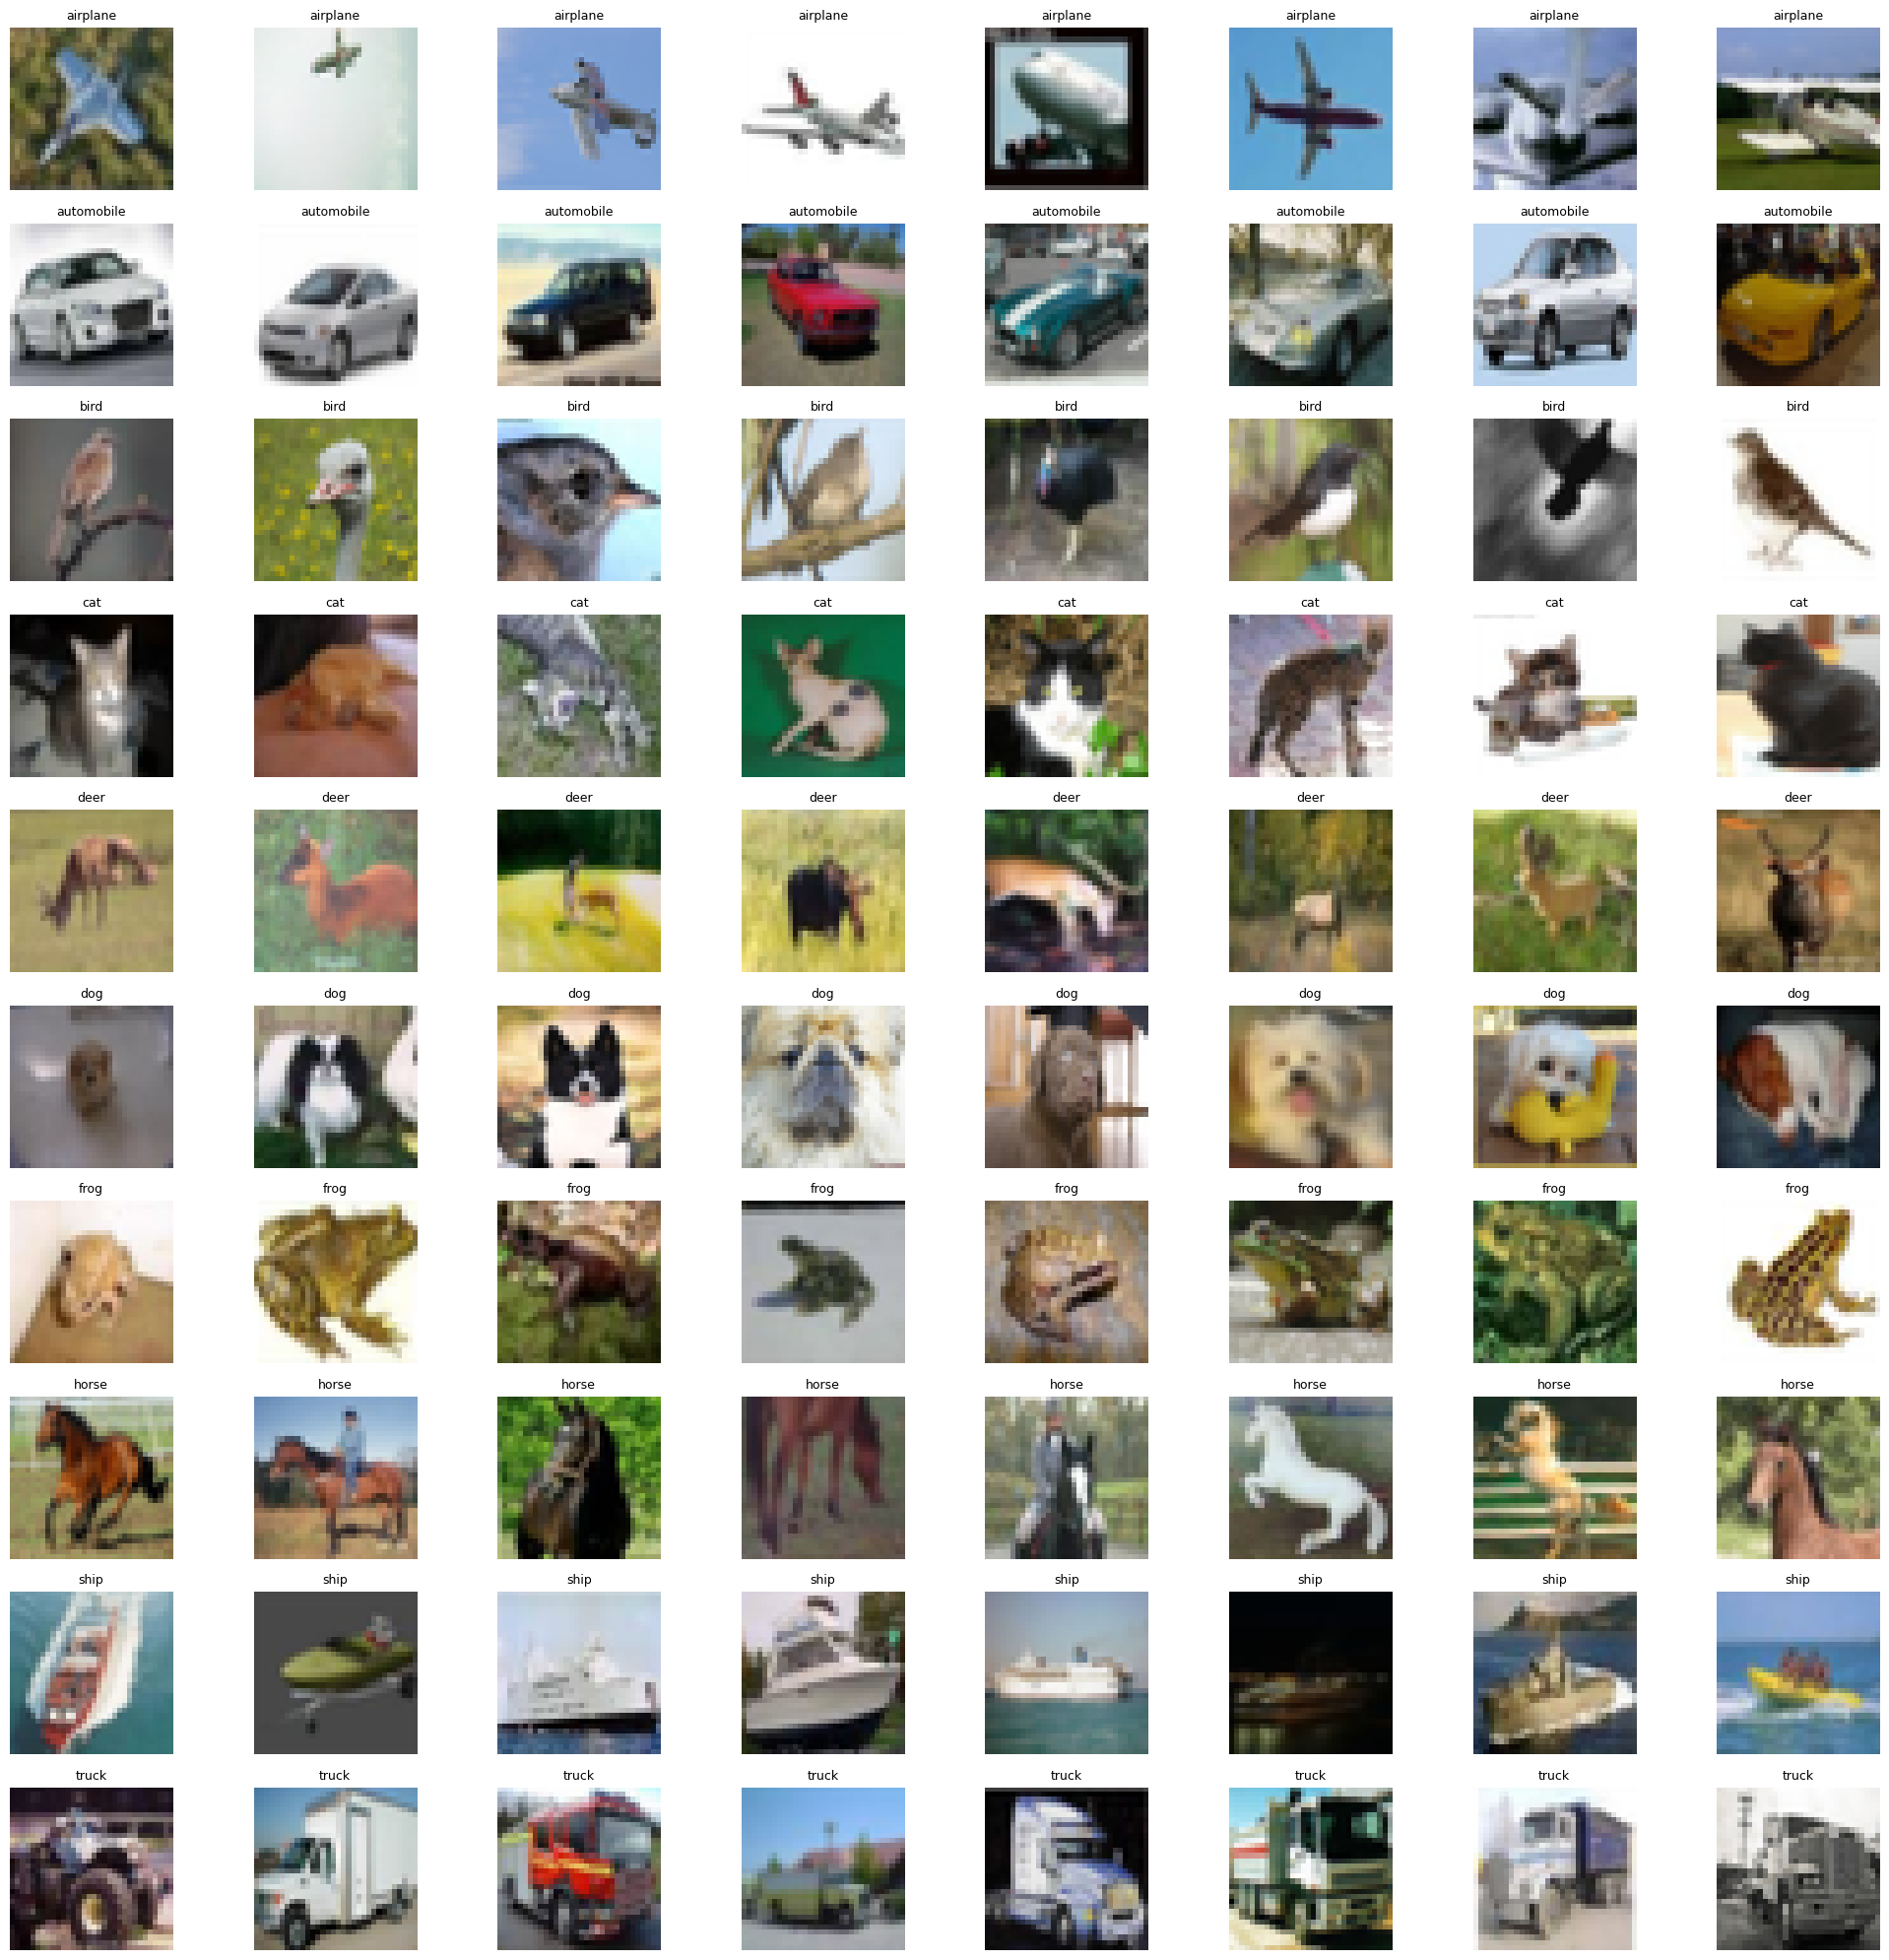

In [6]:
def get_classes_indices(
    x,
    y,
    samples_per_class: int = 5,
    seed: int = 42,
):
    """
    Select sample indices per class.

    Returns
    -------
    selected_indices : np.ndarray
        Flattened array of selected indices
    num_classes : int
        Number of unique classes
    """

    rng = np.random.default_rng(seed)

    y = np.asarray(y)
    unique_classes = np.unique(y)
    num_classes = len(unique_classes)

    selected_indices = []

    for label in unique_classes:
        class_indices = np.where(y == label)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Class {label} has only {len(class_indices)} samples, "
                f"but {samples_per_class} were requested."
            )

        chosen = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )
        selected_indices.extend(chosen)

    return np.array(selected_indices), num_classes


def visualize_data(
    x,
    y,
    samples_per_class: int = 4,
    seed: int = 42,
    class_labels=None,
    cmap: str = "gray"
):
    """
    Visualize sample images per class.

    Parameters
    ----------
    x : array-like
        Image data of shape (N, H, W[, C])
    y : array-like
        Labels of shape (N,)
    samples_per_class : int
        Number of samples to show per class
    seed : int
        Random seed for reproducibility
    class_names : list[str], optional
        Names for each class index
    cmap : str
        Colormap for grayscale images
    """
    
    y = y.squeeze()
    
    selected_indices, num_classes = get_classes_indices(
        x=x,
        y=y,
        samples_per_class=samples_per_class,
        seed=seed
    )

    plt.figure(
    figsize=(num_classes * 2.0, samples_per_class * 2.5))

    for plot_idx, image_idx in enumerate(selected_indices):
        plt.subplot(num_classes, samples_per_class, plot_idx + 1)

        image = x[image_idx]
        label = y[image_idx]

        if image.ndim == 2:  # grayscale
            plt.imshow(image, cmap=cmap)
        else:
            plt.imshow(image)

        if class_labels:
            plt.title(class_labels[label], fontsize=9)
        else:
            plt.title(f"Class {label}", fontsize=9)
        plt.subplots_adjust(bottom=0.1, right=0.2, top=0.2, left=0.1)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_data(xtrain, ytrain, class_labels=class_labels, samples_per_class=8)

Modeling

In [ ]:
def get_model(input_shape, num_classes, activation="relu"):
    
    inputs = keras.Input(shape=input_shape)
    
    x = keras.layers.Rescaling(scale=1./255)(inputs)
    
    x = keras.layers.Conv2D(filters=128, kernel_size=3, padding="same", activation=activation)(x)
    x = keras.layers.MaxPooling2D(pool_size=2)(x)
    
    x = keras.layers.Conv2D(filters=64, kernel_size=3, padding="same", activation=activation)(x)
    x = keras.layers.MaxPooling2D(pool_size=2)(x)
    
    x = keras.layers.Flatten()(x)
    
    x = keras.layers.Dropout(rate=0.2)(x)
    
    outputs = keras.layers.Dense(units=num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.summary()

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy"]
    )

    return model



In [8]:

# hyperparameters
EPOCHS = 10
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.1

input_shape = xtrain.shape[1:]

num_classes = len(np.unique(ytrain))

model = get_model(input_shape=input_shape, num_classes=num_classes)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

history = model.fit(xtrain, ytrain, epochs=EPOCHS, validation_split=VALIDATION_SPLIT, callbacks=[early_stopping])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,346 (462.29 KB)

 Trainable params: 118,346 (462.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.4556 - loss: 1.5294 - val_accuracy: 0.5486 - val_loss: 1.3010
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.5868 - loss: 1.1844 - val_accuracy: 0.6342 - val_loss: 1.0658
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.6286 - loss: 1.0699 - val_accuracy: 0.6586 - val_loss: 0.9963
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.6521 - loss: 0.9943 - val_accuracy: 0.6396 - val_loss: 1.0567
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.6696 - loss: 0.9485 - val_accuracy: 0.6858 - val_loss: 0.9128
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.6842 - loss: 0.9046 - val_accuracy: 0.6868 - val_loss: 0.9095
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.6931 - loss: 0.8815 - val_accuracy: 0.6858 - val_loss: 0.9098
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.7016 -

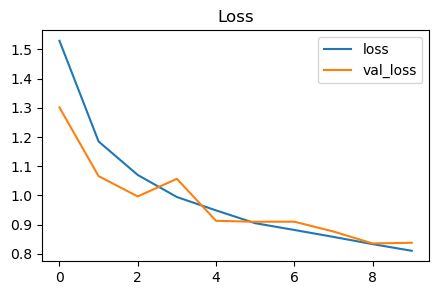

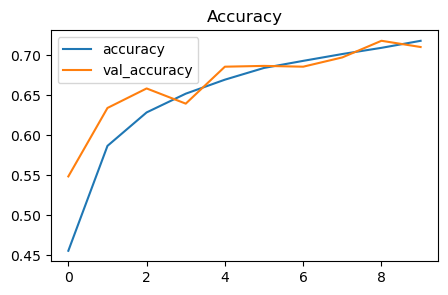

In [9]:
# visualize metrics
def plot_metrics(history, metric: str = "accuracy"):

    all_metrics = list(history.history.keys())
    metrics = [met for met in all_metrics if metric in met]
    plt.figure(figsize=(5, 3))
    for met in metrics:
        plt.plot(history.history.get(met), label=met)
    plt.legend()
    plt.title(metric.capitalize())
    plt.show()
    
    
plot_metrics(history=history, metric="loss")
plot_metrics(history=history, metric="accuracy")

Evaluate model

In [10]:
# get accuracies
train_loss, train_accuracy = model.evaluate(xtrain, ytrain, verbose=0)
test_loss, test_accuracy = model.evaluate(xtest, ytest, verbose=0)
print(f"Train accuracy: {train_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")

Train accuracy: 75.37%
Test accuracy: 69.92%


In [11]:
# get predictions
test_pred = model.predict(xtest)
test_pred = np.argmax(test_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [ ]:
# classification report
report = classification_report(ytest, test_pred, target_names=class_labels)
print(report)


              precision    recall  f1-score   support

    airplane       0.70      0.75      0.72      1000
  automobile       0.83      0.81      0.82      1000
        bird       0.63      0.53      0.58      1000
         cat       0.49      0.51      0.50      1000
        deer       0.68      0.62      0.65      1000
         dog       0.62      0.60      0.61      1000
        frog       0.74      0.80      0.77      1000
       horse       0.80      0.76      0.78      1000
        ship       0.81      0.76      0.78      1000
       truck       0.69      0.85      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



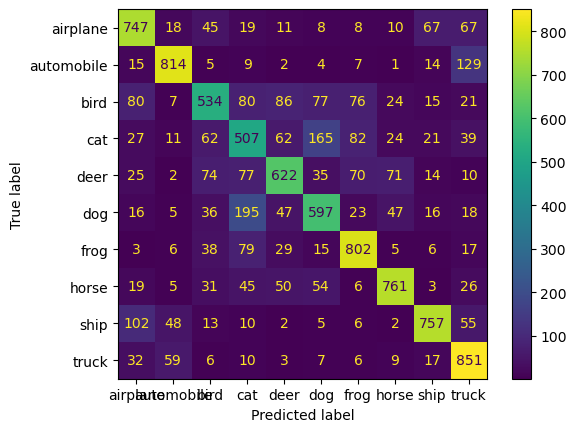

In [ ]:
# plot confusion matrix
cm = confusion_matrix(ytest, test_pred)

display = ConfusionMatrixDisplay(cm, display_labels=class_labels)
display.plot(xticks_rotation="vertical", cmap="Blues")
plt.show()

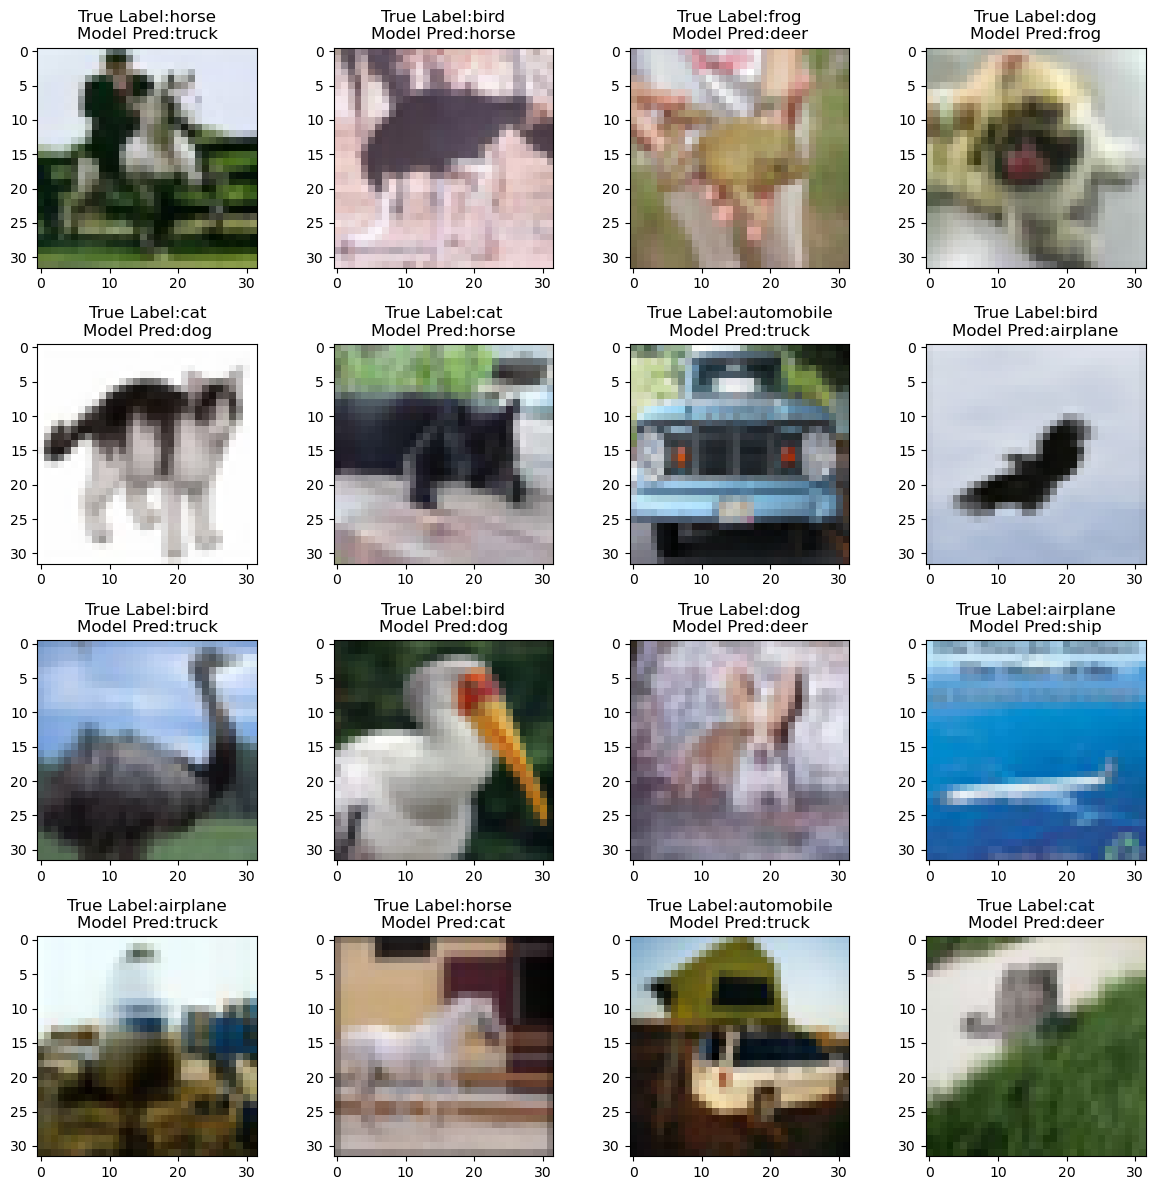

In [14]:
# error analysis
def visualize_wrong_predictions(x, ytrue, ypred, class_labels=None, n_samples=10, seed=42):
    
    ytrue = ytrue.squeeze()
    ypred = ypred.squeeze()

    wrong_predictions = ytrue != ypred
    X_mispredicted = x[wrong_predictions]
    actual_pred = ytrue[wrong_predictions]
    wrong_pred = ypred[wrong_predictions]

    np.random.seed(seed)
    indices = np.random.permutation(len(X_mispredicted))[:n_samples]

    n_wrong = len(wrong_pred)
    if n_samples > n_wrong:
        raise ValueError(f"You can only visualize upto {n_wrong} samples.")

    nrows = int(np.ceil(np.sqrt(n_samples)))
    ncols = int(np.floor(np.sqrt(n_samples)))

    plt.figure(figsize=(nrows*3, ncols*3))
    for subplot_idx, image_idx in enumerate(indices):
        plt.subplot(nrows, ncols, subplot_idx+1)
        plt.imshow(X_mispredicted[image_idx])
        if class_labels:
            title = f"True Label:{class_labels[actual_pred[image_idx]]}\nModel Pred:{class_labels[wrong_pred[image_idx]]}"
        else:
            title = f"True Label:{actual_pred[image_idx]}\nModel Pred:{wrong_pred[image_idx]}"
        
        plt.title(title)
    
    plt.tight_layout()

    plt.show()

visualize_wrong_predictions(xtest, ytest, test_pred, class_labels=class_labels, n_samples=16)

## Transfer Learning

In [15]:
# get available pretrained models
dir(keras.applications)

['ConvNeXtBase',
 'ConvNeXtLarge',
 'ConvNeXtSmall',
 'ConvNeXtTiny',
 'ConvNeXtXLarge',
 'DenseNet121',
 'DenseNet169',
 'DenseNet201',
 'EfficientNetB0',
 'EfficientNetB1',
 'EfficientNetB2',
 'EfficientNetB3',
 'EfficientNetB4',
 'EfficientNetB5',
 'EfficientNetB6',
 'EfficientNetB7',
 'EfficientNetV2B0',
 'EfficientNetV2B1',
 'EfficientNetV2B2',
 'EfficientNetV2B3',
 'EfficientNetV2L',
 'EfficientNetV2M',
 'EfficientNetV2S',
 'InceptionResNetV2',
 'InceptionV3',
 'MobileNet',
 'MobileNetV2',
 'MobileNetV3Large',
 'MobileNetV3Small',
 'NASNetLarge',
 'NASNetMobile',
 'ResNet101',
 'ResNet101V2',
 'ResNet152',
 'ResNet152V2',
 'ResNet50',
 'ResNet50V2',
 'VGG16',
 'VGG19',
 'Xception',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'convnext',
 'densenet',
 'efficientnet',
 'efficientnet_v2',
 'imagenet_utils',
 'inception_resnet_v2',
 'inception_v3',
 'mobilenet',
 'mobilenet_v2',
 'mobilenet_v3',
 'nas

In [16]:
help(keras.applications.mobilenet.preprocess_input)

Help on function preprocess_input in module keras.src.applications.mobilenet:

preprocess_input(x, data_format=None)
    Preprocesses a tensor or Numpy array encoding a batch of images.

    Usage example with `applications.MobileNet`:

    ```python
    i = keras.layers.Input([None, None, 3], dtype="uint8")
    x = ops.cast(i, "float32")
    x = keras.applications.mobilenet.preprocess_input(x)
    core = keras.applications.MobileNet()
    x = core(x)
    model = keras.Model(inputs=[i], outputs=[x])
    result = model(image)
    ```

    Args:
          x: A floating point `numpy.array` or a backend-native tensor,
              3D or 4D with 3 color
              channels, with values in the range [0, 255].
              The preprocessed data are written over the input data
          if the data types are compatible. To avoid this
          behaviour, `numpy.copy(x)` can be used.
          data_format: Optional data format of the image tensor/array. None, means
          the global set

In [ ]:
def feature_extractor(inputs, fine_tune=False, last_layers=20):
    core = keras.applications.MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights="imagenet")
    core.trainable = False
    if fine_tune:
        for layer in core.layers[-last_layers:]:
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
    
    feature_extracted = core(inputs)

    return feature_extracted

def classifier(inputs):
    clf = keras.Sequential([
        keras.layers.Flatten(),
        keras.layers.Dropout(rate=0.2),
        keras.layers.Dense(10, activation="softmax")
    ])

    outputs = clf(inputs)

    return outputs

def final_model(input_shape, fine_tune=False, last_layers=10):
    
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.UpSampling2D(size=(7, 7))(inputs) # upsampling was done to get 32 * 32 image to 224 by 224
    x = keras.applications.mobilenet.preprocess_input(x)
    x = feature_extractor(x, fine_tune=fine_tune, last_layers=last_layers)
    outputs = classifier(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )

    model.summary()
    
    return model


In [18]:
# train model
clf = final_model(input_shape=xtrain.shape[1:], fine_tune=False)
device = tf.config.list_physical_devices("GPU")
if len(device) > 0: # train for epochs if GPU is available
    history = clf.fit(xtrain, ytrain, epochs=10, validation_split=VALIDATION_SPLIT)
else: # train for less epochs
    history = clf.fit(xtrain, ytrain, epochs=3, validation_split=VALIDATION_SPLIT)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 10)             │       627,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885,194 (11.01 MB)

 Trainable params: 627,210 (2.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 676s 476ms/step - accuracy: 0.6432 - loss: 4.9935 - val_accuracy: 0.6914 - val_loss: 5.3226
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 675s 479ms/step - accuracy: 0.7649 - loss: 3.5243 - val_accuracy: 0.7170 - val_loss: 5.3161
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 681s 484ms/step - accuracy: 0.8130 - loss: 2.7960 - val_accuracy: 0.7366 - val_loss: 5.7792


Evaluate

In [19]:
test_loss, test_acc = clf.evaluate(xtest, ytest)
print(f"Test Accuracy: {test_acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 134s 429ms/step - accuracy: 0.7330 - loss: 6.1384
Test Accuracy: 73.30%


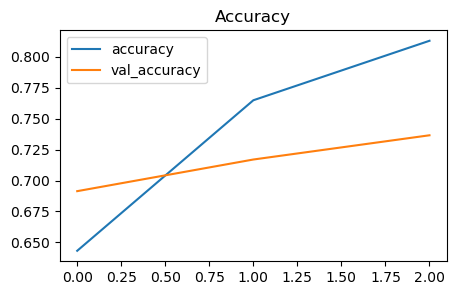

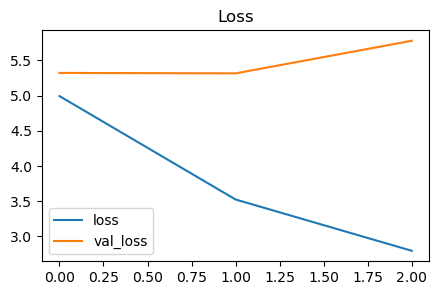

In [20]:
plot_metrics(history=history, metric="accuracy")
plot_metrics(history=history, metric="loss")

In [22]:
test_pred = clf.predict(xtest)
test_pred = np.argmax(test_pred, axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 443ms/step


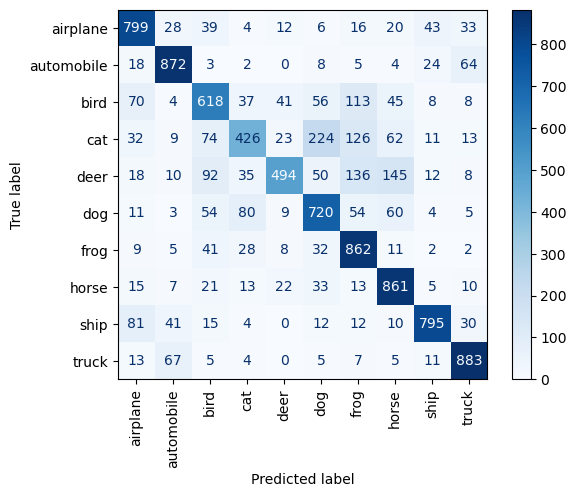

In [23]:
# plot confusion matrix
cm = confusion_matrix(ytest, test_pred)
display = ConfusionMatrixDisplay(cm, display_labels=class_labels)
display.plot(xticks_rotation="vertical", cmap="Blues")
plt.show()

In [24]:
# classification report
report = classification_report(ytest, test_pred, target_names=class_labels)
print(report)


              precision    recall  f1-score   support

    airplane       0.75      0.80      0.77      1000
  automobile       0.83      0.87      0.85      1000
        bird       0.64      0.62      0.63      1000
         cat       0.67      0.43      0.52      1000
        deer       0.81      0.49      0.61      1000
         dog       0.63      0.72      0.67      1000
        frog       0.64      0.86      0.74      1000
       horse       0.70      0.86      0.77      1000
        ship       0.87      0.80      0.83      1000
       truck       0.84      0.88      0.86      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



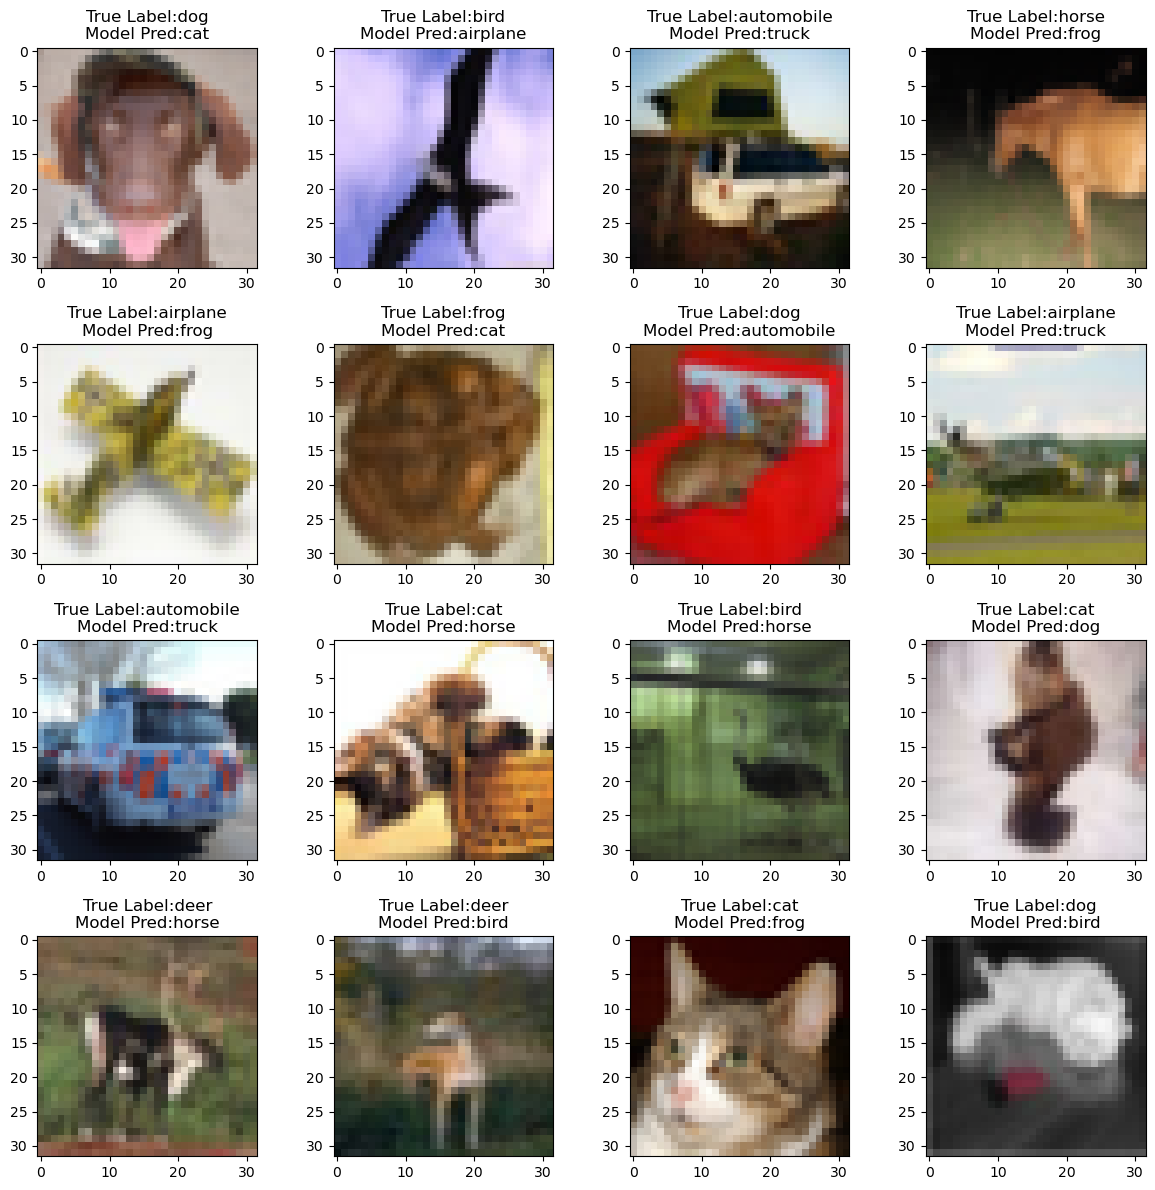

In [25]:
visualize_wrong_predictions(xtest, ytest, test_pred, class_labels=class_labels, n_samples=16)